<a href="https://colab.research.google.com/github/MariaPetrovskaya/Data-Science-for-HR/blob/main/BERT_interview_classification_5labels_EN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interview Outcome Classification with BERT (5 Labels)

Fine-tuning **ruBERT-base** to automatically classify the outcome of a recruitment phone call into one of five categories.

## Label Schema

| Label (model) | Original index | Meaning |
|:---:|:---:|---|
| 0 | 1 | Candidate declined |
| 1 | 2 | Recruiter declined the candidate |
| 2 | 3 | Candidate agreed |
| 3 | 4 | Next steps were discussed |
| 4 | 5 | Candidate actually started the job |

> **Note:** Original index 0 (*call failed for technical reasons*) is excluded from training.

## 1. Installation

In [ ]:
!pip install -q transformers datasets

## 2. Imports

In [ ]:
import os
import gc
import glob

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm, trange
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
)
from torch.utils.data import DataLoader
from torch.optim import AdamW

## 3. Configuration

In [ ]:
# ── Paths ────────────────────────────────────────────────────────────────
DATA_DIR   = "/content/drive/MyDrive/Colab Notebooks/Eurasia Bert for interviews evaluation /dataset 5_cat"
MODEL_DIR  = os.path.join(DATA_DIR, "interview_classifier")

# ── Model ────────────────────────────────────────────────────────────────
BASE_MODEL = "ai-forever/ruBert-base"  # https://huggingface.co/ai-forever/ruBert-base

# ── Training hyperparameters ─────────────────────────────────────────────
NUM_LABELS  = 5
BATCH_SIZE  = 4
MAX_LENGTH  = 512
LEARNING_RATE = 1e-6   # keep small for tiny batches
NUM_EPOCHS  = 3
TEST_SIZE   = 0.2
RANDOM_SEED = 42

# ── Labels ───────────────────────────────────────────────────────────────
LABEL_NAMES = [
    "Candidate declined",
    "Recruiter declined candidate",
    "Candidate agreed",
    "Next steps discussed",
    "Candidate started job",
]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## 4. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 5. Load & Merge Data

In [ ]:
os.chdir(DATA_DIR)

csv_files = glob.glob("*.csv")
print(f"Found {len(csv_files)} CSV file(s): {csv_files}")

df_raw = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
print(f"Total rows loaded: {len(df_raw):,}")

Found 25 CSV file(s): ['data_rec_id_0_2025-04-17.csv', 'data_rec_id_1_2025-04-17.csv', 'data_rec_id_2_2025-04-17.csv', 'data_rec_id_5_2025-04-17.csv', 'data_rec_id_6_2025-04-17.csv', 'data_rec_id_7_2025-04-17.csv', 'data_rec_id_8_2025-04-17.csv', 'data_rec_id_9_2025-04-17.csv', 'data_rec_id_10_2025-04-21.csv', 'data_rec_id_11_2025-04-21.csv', 'data_rec_id_12_2025-04-21.csv', 'data_rec_id_13_2025-04-21.csv', 'data_rec_id_14_2025-04-21.csv', 'data_rec_id_15_2025-04-21.csv', 'data_rec_id_16_2025-04-21.csv', 'data_rec_id_17_2025-04-21.csv', 'data_rec_id_18_2025-04-21.csv', 'data_rec_id_19_2025-04-21.csv', 'data_rec_id_20_2025-04-21.csv', 'data_rec_id_21_2025-04-21.csv', 'data_rec_id_22_2025-04-21.csv', 'data_rec_id_23_2025-04-21.csv', 'data_rec_id_24_2025-04-21.csv', 'data_rec_id_25_2025-04-21.csv', 'data_rec_id_0_2025-04-23.csv']
Total rows loaded: 11,322


## 6. Data Preprocessing

In [ ]:
df = df_raw.copy()
df = df.rename(columns={"result_column": "label"})

# ── Missing values ───────────────────────────────────────────────────────
missing = df["label"].isna().sum()
print(f"Missing labels: {missing}")
df["label"] = df["label"].fillna(0)

# ── Cast to int ──────────────────────────────────────────────────────────
df["label"] = df["label"].astype(int)

print("\nLabel distribution (all data):")
print(df["label"].value_counts().sort_index())

Missing labels: 596

Label distribution (all data):
label
0     681
1    2201
2     401
3    6693
4     673
5     673
Name: count, dtype: int64


In [ ]:
# Preview a few samples per class
pd.options.display.max_colwidth = 300
print(f"Dataset shape: {df.shape}")
df.groupby("label").sample(2, random_state=RANDOM_SEED)

Dataset shape: (11322, 11)


,spk,text,emotion,emotion_audio,end,part,word,lemma,start,label,id_column
9225,0,пдельник заседание,neutral,angry,249.500000,СУЩЕСТВИТЕЛЬНОЕ,пдельник,пдельник,249.000000,0,NaN
1393,1,так хорошо тогда давайте анкету менеджеру передам и менеджер тогда с вами свяжется,neutral,positive,172.176923,ГЛАГОЛ,передам,передать,171.823077,0,NaN
6429,1,за пятнадцать смен вы двести двадцать пять тысяч не заработаете я вам сказала сколько зарплата от трех до шести с половиной за смену,neutral,neutral,213.300000,СУЩЕСТВИТЕЛЬНОЕ,тысяч,тысяча,213.000000,1,15.0
10595,0,за зарплата за за весь ноябрь,neutral,neutral,154.166667,СУЩЕСТВИТЕЛЬНОЕ,зарплата,зарплата,153.783333,1,25.0
7968,1,судимости либо какие то медицинские ограничения что то из этого есть,neutral,neutral,29.636364,СОЮЗ,либо,либо,29.318182,2,19.0
8050,0,здравствуйте,speech,neutral,1.800000,ГЛАГОЛ,здравствуйте,здравствовать,1.100000,2,20.0
3494,1,стажировка не оплачивается,neutral,neutral,167.700000,ЧАСТИЦА,не,не,167.100000,3,11.0
6914,1,ну по поводу остановки вам еще менеджер скажет,neutral,neutral,324.200000,ГЛАГОЛ,скажет,сказать,323.787500,3,16.0
187,0,и плюс у вас будет за выработку,neutral,neutral,166.314286,СОЮЗ,и,и,166.000000,4,25.0
422,0,да мне просто интересно какая компания потому что я у нас не вижу чтобы с нашей напрер компании никто не мог звонить,neutral,neutral,331.936364,СОЮЗ,чтобы,чтобы,331.590909,4,25.0


## 7. Build Hugging Face Dataset

In [ ]:
# Exclude label 0 (call failed for technical reasons — not a classification outcome)
df_train = df[df["label"] > 0].copy()

# Shift labels to 0-based: original 1-5 → model 0-4
df_train["label"] = df_train["label"] - 1

print("Training label distribution:")
print(df_train["label"].value_counts().sort_index())

hf_dataset = Dataset.from_dict(
    {"text": df_train["text"].tolist(), "label": df_train["label"].tolist()}
).train_test_split(test_size=TEST_SIZE, seed=RANDOM_SEED)

print("\nDataset splits:")
print(hf_dataset)

Training label distribution:
label
0    2201
1     401
2    6693
3     673
4     673
Name: count, dtype: int64

Dataset splits:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8512
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2129
    })
})


## 8. Tokenisation

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

tokenized = hf_dataset.map(tokenize, batched=True, remove_columns=["text"])
print(tokenized)

config.json:   0%|          | 0.00/590 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/8512 [00:00<?, ? examples/s]

Map:   0%|          | 0/2129 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8512
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2129
    })
})


## 9. DataLoaders

In [ ]:
collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_loader = DataLoader(
    tokenized["train"], shuffle=True, batch_size=BATCH_SIZE, collate_fn=collator
)
val_loader = DataLoader(
    tokenized["test"], shuffle=False, batch_size=BATCH_SIZE, collate_fn=collator
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 2128 | Val batches: 533


## 10. Model

We use [`BertForSequenceClassification`](https://huggingface.co/docs/transformers/model_doc/bert#transformers.BertForSequenceClassification) from `transformers`.  
It adds a dropout + linear head on top of the `[CLS]` token representation and computes cross-entropy loss when labels are provided.

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL, num_labels=NUM_LABELS
)
model.to(DEVICE)
print(model.config)

pytorch_model.bin:   0%|          | 0.00/716M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/716M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ai-forever/ruBert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "directionality": "bidi",
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2,
    "LABEL_3": 3,
    "LABEL_4": 4
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "pooler_size_per_head": 128,
  "pooler_type": "first_token_transform",
  "tie_word_embeddings": tru

## 11. Optimizer

In [ ]:
# AdamW is generally preferred over plain Adam for transformers
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

# Free unused GPU memory before training
gc.collect()
torch.cuda.empty_cache()

## 12. Training Loop

In [ ]:
def evaluate(loader):
    """Run evaluation; return (mean_loss, predictions, targets)."""
    model.eval()
    losses, preds, targets = [], [], []
    for batch in tqdm(loader, desc="Eval", leave=False):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        with torch.no_grad():
            out = model(**batch)
        losses.append(out.loss.item())
        preds.extend(out.logits.argmax(1).tolist())
        targets.extend(batch["labels"].tolist())
    return np.mean(losses), preds, targets


train_losses = []

for epoch in trange(NUM_EPOCHS, desc="Epochs"):
    model.train()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=True)

    for batch in pbar:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = model(**batch)
        out.loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        train_losses.append(out.loss.item())
        pbar.set_description(f"Epoch {epoch+1} | loss: {np.mean(train_losses[-100:]):.3f}")

    val_loss, val_preds, val_targets = evaluate(val_loader)
    acc = np.mean(np.array(val_targets) == np.array(val_preds))
    print(
        f"[Epoch {epoch+1}] "
        f"train_loss={np.mean(train_losses[-100:]):.3f}  "
        f"val_loss={val_loss:.3f}  "
        f"val_acc={acc:.3f}"
    )

Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/2128 [00:00<?, ?it/s]

Eval:   0%|          | 0/533 [00:00<?, ?it/s]

[Epoch 1] train_loss=0.877  val_loss=0.808  val_acc=0.669


Epoch 2:   0%|          | 0/2128 [00:00<?, ?it/s]

Eval:   0%|          | 0/533 [00:00<?, ?it/s]

[Epoch 2] train_loss=0.506  val_loss=0.486  val_acc=0.818


Epoch 3:   0%|          | 0/2128 [00:00<?, ?it/s]

Eval:   0%|          | 0/533 [00:00<?, ?it/s]

[Epoch 3] train_loss=0.378  val_loss=0.331  val_acc=0.871


## 13. Evaluation

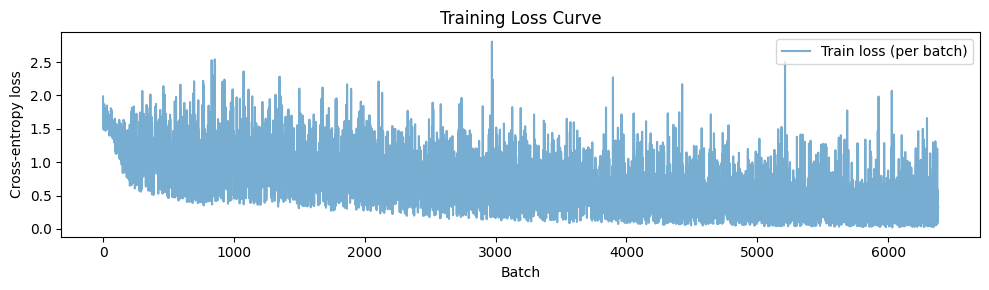

In [ ]:
# Loss curve
plt.figure(figsize=(10, 3))
plt.plot(train_losses, alpha=0.6, label="Train loss (per batch)")
plt.xlabel("Batch")
plt.ylabel("Cross-entropy loss")
plt.title("Training Loss Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
_, val_preds, val_targets = evaluate(val_loader)

print("Classification Report:")
print(classification_report(val_targets, val_preds, target_names=LABEL_NAMES))

print("Confusion Matrix:")
print(confusion_matrix(val_targets, val_preds))

Eval:   0%|          | 0/533 [00:00<?, ?it/s]

Classification Report:
                              precision    recall  f1-score   support

          Candidate declined       0.86      0.90      0.88       467
Recruiter declined candidate       0.86      0.49      0.63        77
            Candidate agreed       0.96      0.98      0.97      1313
        Next steps discussed       0.35      0.23      0.28       124
       Candidate started job       0.47      0.54      0.50       148

                    accuracy                           0.87      2129
                   macro avg       0.70      0.63      0.65      2129
                weighted avg       0.86      0.87      0.86      2129

Confusion Matrix:
[[ 420    6   41    0    0]
 [  29   38   10    0    0]
 [  24    0 1288    1    0]
 [   5    0    2   28   89]
 [  12    0    6   50   80]]


## 14. Save Model

In [ ]:
# Ensure tensors are contiguous before saving
for param in model.parameters():
    param.data = param.data.contiguous()

model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
print(f"Model saved to: {MODEL_DIR}")
!ls "{MODEL_DIR}" -alsh

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/Colab Notebooks/Eurasia Bert for interviews evaluation /dataset 5_cat/interview_classifier
total 684M
1.5K -rw------- 1 root root 1.2K Apr 24 17:33 config.json
681M -rw------- 1 root root 681M Apr 24 17:33 model.safetensors
 512 -rw------- 1 root root  351 Apr 24 17:33 tokenizer_config.json
3.6M -rw------- 1 root root 3.6M Apr 24 17:33 tokenizer.json


## 15. Load Model & Run Inference

In [ ]:
# Load from disk (useful when resuming from a saved checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).to(DEVICE)
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
def classify(text: str) -> dict:
    """
    Classify a single text string.

    Returns a dict mapping each label name to its predicted probability.
    """
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    return {name: float(f"{p:.4f}") for name, p in zip(LABEL_NAMES, probs)}

In [ ]:
# Example predictions
test_phrases = [
    " К сожалению у нас нет такой вакансии",  # recruiter declines
    " мы с вами свяжемся'",                         # ambiguous / next steps
    " готов приступить в понедельник",                  # candidate agreed
]

for phrase in test_phrases:
    result = classify(phrase)
    top = max(result, key=result.get)
    print(f"\nText : {phrase}")
    print(f"Top  : {top} ({result[top]:.1%})")
    for label, prob in result.items():
        print(f"  {label:<30} {prob:.1%}")


Text :  К сожалению у нас нет такой вакансии
Top  : Candidate declined (58.1%)
  Candidate declined             58.1%
  Recruiter declined candidate   14.6%
  Candidate agreed               2.8%
  Next steps discussed           13.1%
  Candidate started job          11.4%

Text :  мы с вами свяжемся'
Top  : Candidate agreed (88.9%)
  Candidate declined             5.5%
  Recruiter declined candidate   2.2%
  Candidate agreed               88.9%
  Next steps discussed           1.6%
  Candidate started job          1.9%

Text :  готов приступить в понедельник
Top  : Candidate agreed (97.4%)
  Candidate declined             1.4%
  Recruiter declined candidate   0.5%
  Candidate agreed               97.4%
  Next steps discussed           0.2%
  Candidate started job          0.4%
